In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import talib as ta

from utilities import check_stationarity

In [34]:
data = pd.read_csv("data/data.csv", index_col=0, parse_dates=True)
data.head()

,close,high,low,volume
Date,,,,
2023-01-03,1.843226,1.861659,1.824794,1624100
2023-01-04,1.834010,1.880091,1.834010,1706800
2023-01-05,1.834010,1.843226,1.824794,1391300
2023-01-06,1.880091,1.880091,1.834010,3364000
2023-01-09,1.898523,1.898523,1.880091,3771500


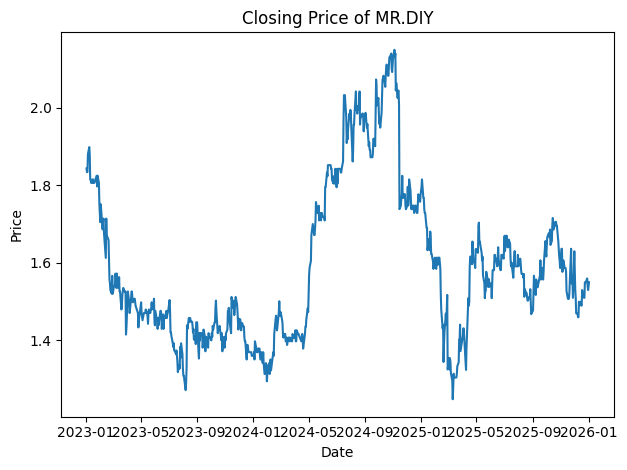

In [35]:
fig, ax = plt.subplots(1, 1)

ax.plot(data['close'])
ax.set_title("Closing Price of MR.DIY")
ax.set_ylabel("Price")
ax.set_xlabel(data.index.name)

plt.tight_layout()
plt.show()

Feature Engineering

In [36]:
# 'future_1d_return', 'signal' for buy or sell
data['future_1d_return'] = data['close'].pct_change().shift(-1)
data['signal'] = np.where(data['future_1d_return'] > 0, 1, 0)
print(data.head())
print(f"Length of future_1d_return: {len(data['future_1d_return'])}, \
      Length of 1's (buy signals): {len(data[data['signal'] == 1])}")

               close      high       low   volume  future_1d_return  signal
Date                                                                       
2023-01-03  1.843226  1.861659  1.824794  1624100         -0.005000       0
2023-01-04  1.834010  1.880091  1.834010  1706800          0.000000       0
2023-01-05  1.834010  1.843226  1.824794  1391300          0.025126       1
2023-01-06  1.880091  1.880091  1.834010  3364000          0.009804       1
2023-01-09  1.898523  1.898523  1.880091  3771500         -0.009709       0
Length of future_1d_return: 736,       Length of 1's (buy signals): 295


In [37]:
# pct_change_1d, pct_change_5d, rsi, adx, volatility

data['pct_change_1d'] = data['close'].pct_change()
data['pct_change_5d'] = data['close'].pct_change(5)

p = 10 # period of last two weeks: 10. 1 week has 10 trading days
data['rsi'] = ta.RSI(data['close'], timeperiod=p)
data['adx'] = ta.ADX(data['high'], data['low'], data['close'], timeperiod=p)

data['sma'] = data['close'].rolling(window=p).mean()
data['corr'] = data['close'].rolling(window=p).corr(data['sma'])

data['volatility'] = data['pct_change_1d'].rolling(window=p, min_periods=p).std() * 100

print(f"Length of data: {data.shape}")
data.dropna(inplace=True)
print(f"Length of data after dropping NaN values: {data.shape}")

Length of data: (736, 13)
Length of data after dropping NaN values: (716, 13)


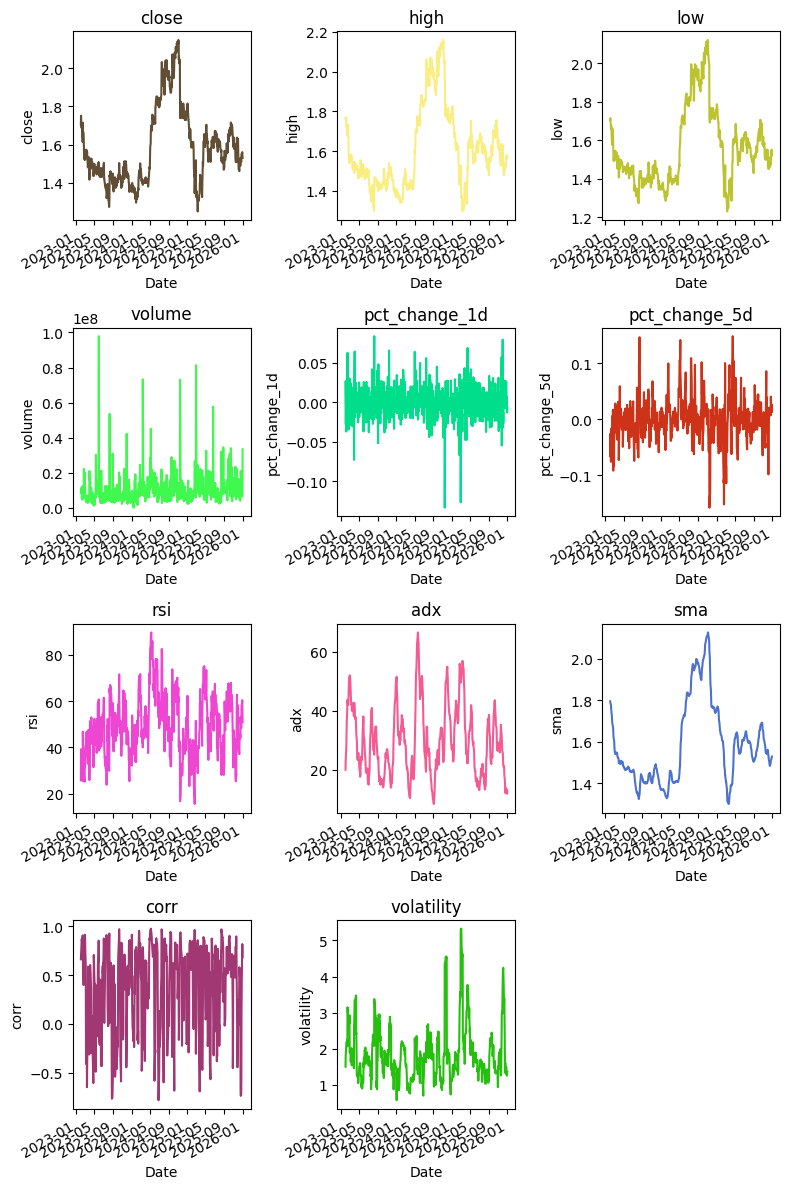

In [39]:
features = ['close', 'high', 'low', 'volume', 'pct_change_1d', 'pct_change_5d',
            'rsi', 'adx', 'sma', 'corr', 'volatility']
target = 'signal'

X = data[features].copy()

y = data[target].copy()

ncolumns = 3
nrows = (X.shape[1] + ncolumns-1) // ncolumns

i=1
for feature in X.columns:
    plt.subplot(nrows, ncolumns, i)

    X[feature].plot(figsize=(8, 12),color=np.random.rand(3))
    plt.ylabel(feature)
    plt.title(feature)
    i += 1

plt.tight_layout()
plt.show()

In [40]:
# Check features for stationarity and drop non-stationary features

ls = []
for column in X.columns:
    if check_stationarity(X[column]) == "non-stationary":
        ls.append(column)
        X.drop(columns=[column], inplace=True)
    print()

print(f"Dropped features: {ls}")

ADF Statistic: -2.0026835360436404
p-value: 0.28539770315833046
close is non-stationary. Failed to reject null hypothesis

ADF Statistic: -1.8322076877955877
p-value: 0.3645927279445931
high is non-stationary. Failed to reject null hypothesis

ADF Statistic: -1.9602769447674027
p-value: 0.3042571332790196
low is non-stationary. Failed to reject null hypothesis

ADF Statistic: -7.933609505603054
p-value: 3.4603143993301803e-12
volume is stationary. Null hypothesis rejected

ADF Statistic: -30.10924968601948
p-value: 0.0
pct_change_1d is stationary. Null hypothesis rejected

ADF Statistic: -4.785468498251615
p-value: 5.79760882645376e-05
pct_change_5d is stationary. Null hypothesis rejected

ADF Statistic: -5.633132133520891
p-value: 1.0780645032171144e-06
rsi is stationary. Null hypothesis rejected

ADF Statistic: -4.847685814623384
p-value: 4.404337886583477e-05
adx is stationary. Null hypothesis rejected

ADF Statistic: -1.503153127350024
p-value: 0.5319509592087918
sma is non-station

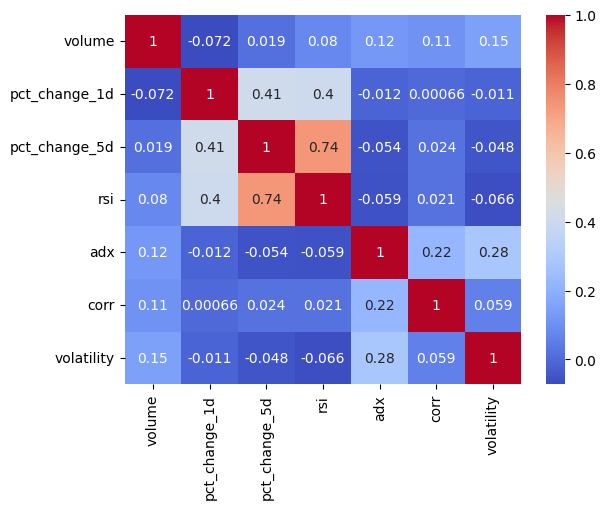

In [41]:
import seaborn as sns

plt.figure()
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.show()

In [42]:
# Drop 'pct_change_5d' due to correlation of 0.74 with rsi
X.drop(columns=['pct_change_5d'], inplace=True)

In [43]:
# Final features

list(X.columns)

['volume', 'pct_change_1d', 'rsi', 'adx', 'corr', 'volatility']

In [45]:
# Add closing price to features for strategy evaluation later
X = pd.concat([data['close'].copy(), X], axis=1)
X.head()

,close,volume,pct_change_1d,rsi,adx,corr,volatility
Date,,,,,,,
2023-02-02,1.704984,8523200,-0.026316,25.717409,20.038163,0.662247,1.503281
2023-02-03,1.751065,9219400,0.027027,39.158280,23.303452,0.701774,1.806856
2023-02-07,1.686552,11662300,-0.036842,30.557384,27.484320,0.837257,2.094658
2023-02-08,1.704984,5665300,0.010929,35.083919,31.247101,0.872249,2.160629
2023-02-09,1.714200,6074700,0.005405,37.352556,33.787339,0.837857,2.182699


Training and Testing Set Split

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False) # no random shuffling for timeseries data

print(f"Shape of\nX: {X.shape}, y: {y.shape}\nX_train: {X_train.shape}, y_train: {y_train.shape} \
    \nX_test: {X_test.shape}, y_test: {y_test.shape}")

Shape of
X: (716, 7), y: (716,)
X_train: (572, 7), y_train: (572,)     
X_test: (144, 7), y_test: (144,)


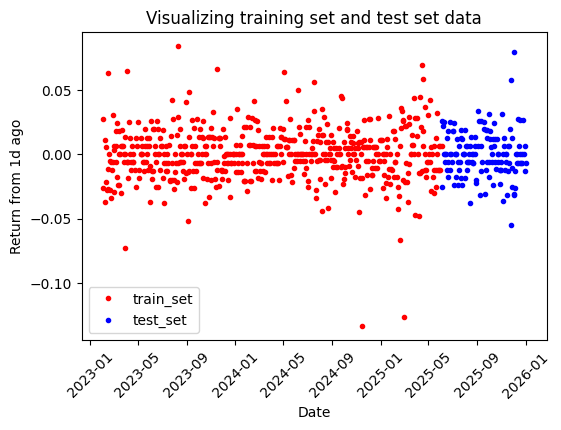

In [ ]:
train_set = pd.concat([X_train, y_train], axis=1)
test_set = pd.concat([X_test, y_test], axis=1)

fig, ax = plt.subplots(1, 1, figsize=(6,4))

ax.plot(train_set['pct_change_1d'], label='train_set', marker='.', linestyle='None', color='r')
ax.plot(test_set['pct_change_1d'], label='test_set', marker='.', linestyle='None', color='b')
ax.set_title('Visualizing training set and test set data')
ax.set_ylabel('Return from 1d ago')
ax.set_xlabel('Date')
ax.tick_params(axis='x', rotation=45)

plt.legend()
plt.show()

In [55]:
# Save training set and test set for model training

train_set.to_csv("data/train_set.csv")
test_set.to_csv("data/test_set.csv")